In [0]:
fligths = spark.read.table('flights')
bookings = spark.read.table('bookings')
preferences = spark.read.table('preferences')

In [0]:
import pandas as pd
from matplotlib import pyplot as plt 
from pyspark.sql.functions import *

joined = bookings.join(
    fligths,
    'flight_id',
    'left'
)

+---------+-------+
|  airline|revenue|
+---------+-------+
|Air India|  68000|
|    Akasa|  62000|
|   Indigo|  90000|
|  Vistara|  71500|
+---------+-------+

None


<Figure size 800x500 with 0 Axes>

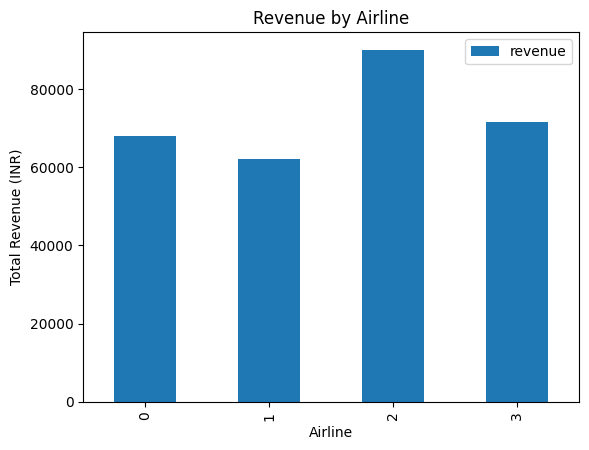

In [0]:
rev_airline = joined.groupBy('airline').agg(sum('ticket_price').alias('revenue'))
print(rev_airline.show())

rev_airline = rev_airline.toPandas()
plt.figure(figsize=(8, 5))
rev_airline.plot(kind="bar")
plt.title("Revenue by Airline")
plt.ylabel("Total Revenue (INR)")
plt.xlabel("Airline")
plt.show()

+---------------+-------+
|   travel_class|revenue|
+---------------+-------+
|       Business| 122000|
|Premium Economy|  81500|
|        Economy|  88000|
+---------------+-------+

None


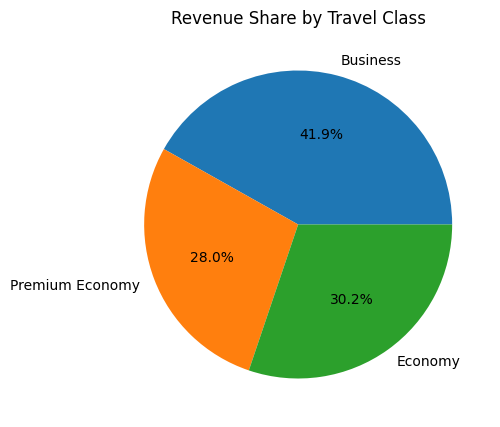

In [0]:
rev_class = joined.groupBy('travel_class').agg(sum('ticket_price').alias('revenue'))
print(rev_class.show())

rev_class = rev_class.toPandas()
plt.figure(figsize=(8, 5))
plt.pie(rev_class['revenue'],
    labels=rev_class['travel_class'], autopct="%1.1f%%")
plt.title("Revenue Share by Travel Class")
plt.show()

status,count
On Time,9
Delayed,4
Cancelled,2


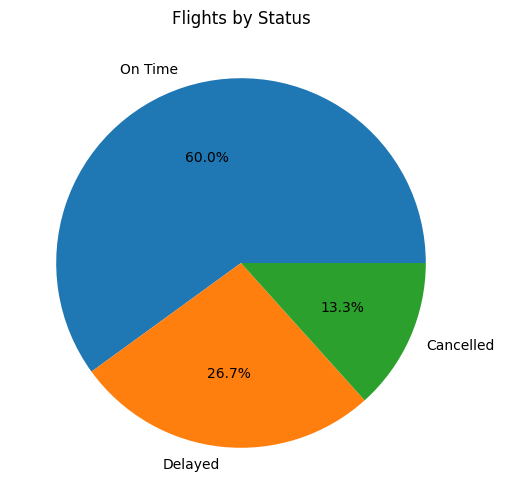

In [0]:
fligth_status = fligths.groupBy("status").count()
display(fligth_status)

fligth_status = fligth_status.toPandas()
plt.figure(figsize=(6, 6))
plt.pie(fligth_status['count'],labels=fligth_status['status'],autopct="%1.1f%%" )
plt.title("Flights by Status")
plt.show()

route,flight_count
Bangalore -> Mumbai,1
Kolkata -> Bangalore,1
Hyderabad -> Kolkata,1
Delhi -> Chennai,1
Hyderabad -> Goa,1
Chennai -> Pune,1
Hyderabad -> Delhi,1
Delhi -> Mumbai,1
Bangalore -> Hyderabad,1
Mumbai -> Hyderabad,1


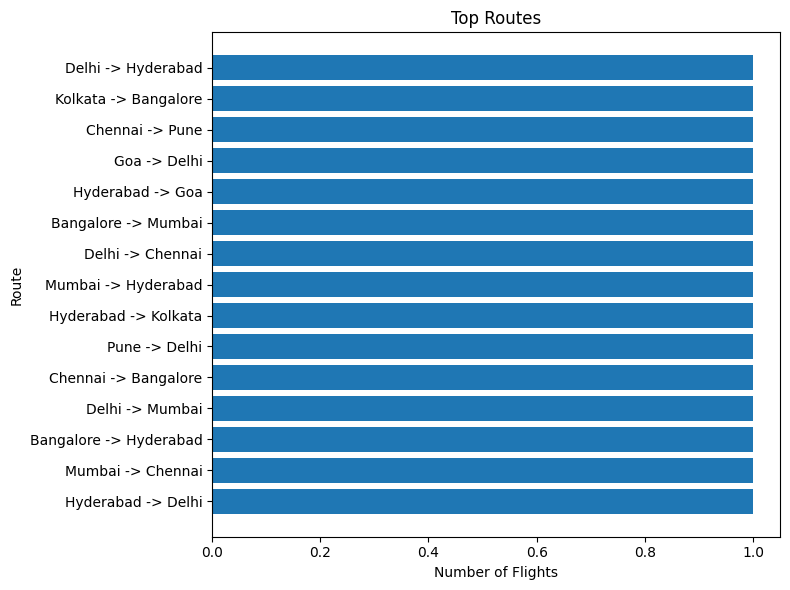

In [0]:
top_routes = fligths.withColumn(
    "route",
    concat_ws(" -> ", col("from_city"), col("to_city"))
).groupBy("route").agg(
    count("*").alias("flight_count")
).orderBy(col("flight_count").desc())
display(top_routes)

top_routes= top_routes.toPandas()
plt.figure(figsize=(8, 6))
plt.barh(
    top_routes["route"],
    top_routes["flight_count"]
)
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.title("Top Routes")
plt.tight_layout()
plt.show()

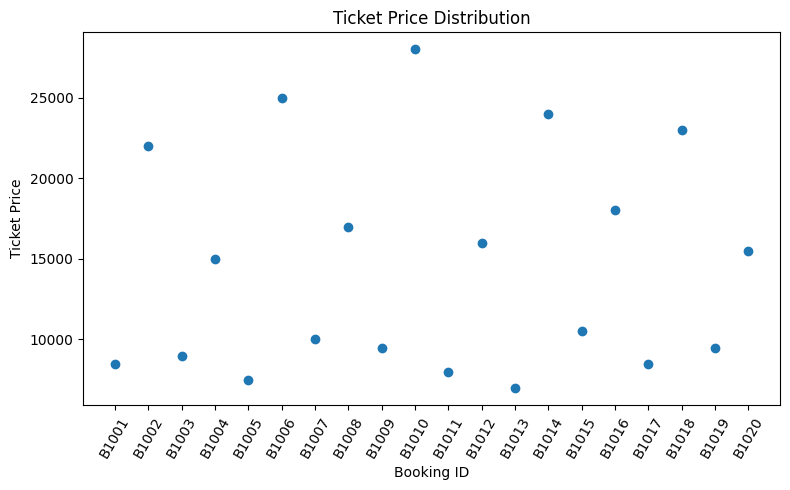

In [0]:
ticket_price = bookings.select(
    "booking_id",
    "ticket_price"
)
ticket_price = ticket_price.toPandas()

plt.figure(figsize=(8,5))
plt.scatter(
    ticket_price["booking_id"],
    ticket_price["ticket_price"]
)

plt.xlabel("Booking ID")
plt.xticks(rotation=60)
plt.ylabel("Ticket Price")
plt.title("Ticket Price Distribution")
plt.tight_layout()
plt.show()